# Misión: Predicción de Cancelación de Clientes (Churn)
## 1. Importación de Librerías y Carga de Datos
En esta etapa inicial, importaremos las herramientas necesarias de Python (Pandas, Numpy, Scikit-Learn, Seaborn, Matplotlib) y cargaremos nuestro dataset procesado para comenzar con el modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn para preprocesamiento, modelado y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset
df = pd.read_csv("TelecomX_Procesado.csv")
print("Vista inicial de los datos:")
display(df.head())

Vista inicial de los datos:


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Contrato,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,One year,Si,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Si,Masculino,0,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Month-to-month,Si,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Si,Masculino,1,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Month-to-month,Si,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Si,Femenino,1,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Month-to-month,Si,Mailed check,83.9,267.40,2.80


## 2. Eliminación de Columnas que no aportan valor
Eliminaremos columnas que actúan como identificadores únicos, como el `ID_Cliente`. Estas columnas no ayudan a predecir la cancelación e introducen ruido en el modelo, ya que el algoritmo podría intentar encontrar patrones irreales en identificadores aleatorios.

In [2]:
# Eliminar ID_Cliente si existe en el dataset
if 'ID_Cliente' in df.columns:
    df = df.drop('ID_Cliente', axis=1)
    print("Columna 'ID_Cliente' eliminada exitosamente.")
else:
    print("La columna 'ID_Cliente' ya no existe en el dataset.")

Columna 'ID_Cliente' eliminada exitosamente.


## 3. Análisis de Proporción y Desbalanceo de Clases
Calcularemos la proporción de clientes que cancelaron (clase positiva) frente a los que permanecieron (clase negativa). Un desbalance fuerte puede hacer que el modelo se sesgue hacia la clase mayoritaria. Transformaremos también la variable objetivo a formato numérico (0 y 1).

Conteo de clientes por clase:
Evasion
0    5174
1    1869
Name: count, dtype: int64

Proporción de clientes por clase (%):
Evasion
0    73.463013
1    26.536987
Name: proportion, dtype: float64


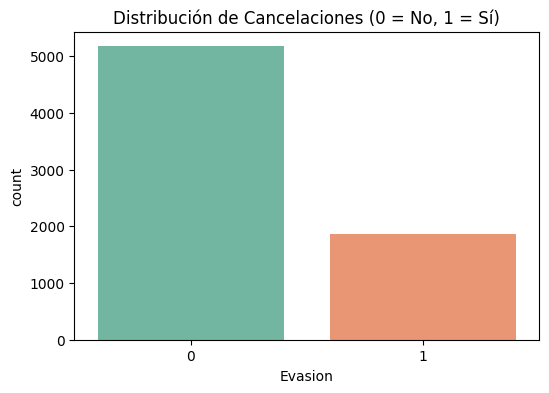

In [3]:
# Mapear Target a numérico
df['Evasion'] = df['Evasion'].map({'Si': 1, 'No': 0, 'Yes': 1})

# Calcular proporciones
class_counts = df['Evasion'].value_counts()
class_props = df['Evasion'].value_counts(normalize=True) * 100

print("Conteo de clientes por clase:")
print(class_counts)
print("\nProporción de clientes por clase (%):")
print(class_props)

# Gráfica de desbalanceo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Evasion', palette='Set2')
plt.title('Distribución de Cancelaciones (0 = No, 1 = Sí)')
plt.show()

## 4. Codificación de Variables Categóricas (One-Hot Encoding)
Para que los algoritmos de Machine Learning puedan procesar las características, transformaremos las variables categóricas de texto a formato numérico utilizando el método One-Hot Encoding.

In [4]:
# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding (drop_first=True evita multicolinealidad)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Dimensiones del dataset tras el One-Hot Encoding: {df_encoded.shape}")

Dimensiones del dataset tras el One-Hot Encoding: (7043, 32)


## 5. División del Conjunto de Datos (Train/Test)
Dividiremos los datos en 80% para entrenamiento y 20% para prueba. Usaremos una división estratificada (`stratify=y`) para asegurar que la proporción de cancelaciones se mantenga constante en ambos conjuntos.

In [5]:
# Separar características (X) y variable objetivo (y)
X = df_encoded.drop('Evasion', axis=1)
y = df_encoded['Evasion']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del set de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño del set de prueba: {X_test.shape[0]} filas")

Tamaño del set de entrenamiento: 5634 filas
Tamaño del set de prueba: 1409 filas


## 6. Normalización y Estandarización de Datos
**Justificación:**
Crearemos al menos dos modelos: **Regresión Logística** y **Random Forest**.
* **Regresión Logística:** Es sensible a la escala de los datos, ya que calcula coeficientes basados en optimización matemática. Por lo tanto, **aplicaremos normalización** para que variables grandes (como Cargos_Totales) no dominen la ecuación.
* **Random Forest:** Es un modelo basado en árboles que realiza divisiones condicionales. No depende de la escala de los datos ni de distancias, por lo que **no aplicaremos normalización** al entrenar este modelo específico.

In [6]:
# Escalar datos SOLO para los modelos que lo requieren (Ej: Regresión Logística)
scaler = StandardScaler()

# Ajustar el escalador solo con los datos de entrenamiento para evitar fugas de información
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Entrenamiento de Modelos y Manejo del Desbalanceo
Para manejar el desbalanceo (73% vs 26%), utilizaremos el parámetro `class_weight='balanced'` integrado en los algoritmos. Esto instruye a los modelos a penalizar más fuertemente los errores cometidos al clasificar la clase minoritaria (los que cancelan).

In [8]:
# --- Modelo 1: Regresión Logística (CON Normalización) ---
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# Predicciones Train y Test
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

# --- Modelo 2: Random Forest (SIN Normalización) ---
rf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf.fit(X_train, y_train)

# Predicciones Train y Test
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

## 8. Evaluación de Modelos y Análisis de Overfitting / Underfitting
Calcularemos la Exactitud (Accuracy), Precisión, Recall, F1-Score y mostraremos las Matrices de Confusión.
Además, compararemos las métricas de entrenamiento vs prueba para detectar **Overfitting** (Sobreajuste) o **Underfitting** (Subajuste).

--- Regresión Logística (Train) ---
Exactitud (Accuracy): 0.7515
Precisión: 0.5204
Recall: 0.8107
F1-score: 0.6339

--- Regresión Logística (Test) ---
Exactitud (Accuracy): 0.7395
Precisión: 0.5060
Recall: 0.7834
F1-score: 0.6149

--- Random Forest (Train) ---
Exactitud (Accuracy): 0.9977
Precisión: 0.9927
Recall: 0.9987
F1-score: 0.9957

--- Random Forest (Test) ---
Exactitud (Accuracy): 0.7864
Precisión: 0.6308
Recall: 0.4706
F1-score: 0.5391



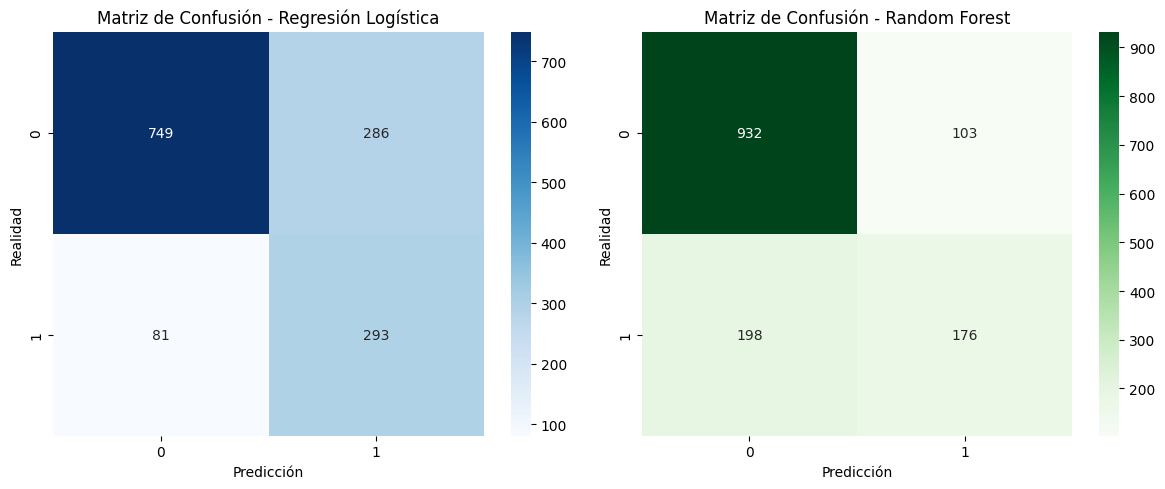

In [9]:
# Función para imprimir métricas
def print_metrics(y_true, y_pred, model_name, dataset_type):
    print(f"--- {model_name} ({dataset_type}) ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score: {f1_score(y_true, y_pred):.4f}\n")

# Métricas Regresión Logística
print_metrics(y_train, y_pred_lr_train, "Regresión Logística", "Train")
print_metrics(y_test, y_pred_lr_test, "Regresión Logística", "Test")

# Métricas Random Forest
print_metrics(y_train, y_pred_rf_train, "Random Forest", "Train")
print_metrics(y_test, y_pred_rf_test, "Random Forest", "Test")

# Gráfica: Matrices de Confusión
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
cm_rf = confusion_matrix(y_test, y_pred_rf_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusión - Regresión Logística")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Realidad")

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Matriz de Confusión - Random Forest")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Realidad")
plt.tight_layout()
plt.show()

### 🧠 Análisis Crítico de los Modelos
* **Regresión Logística:** Mantiene un rendimiento consistente entre Train (F1 = 0.63) y Test (F1 = 0.61). Generaliza bien y no presenta Overfitting. Su **Recall es del 78%**, lo que significa que es excelente detectando a los clientes que realmente se van a fugar.
* **Random Forest:** Presenta un caso severo de **Overfitting**. En los datos de entrenamiento obtiene métricas casi perfectas (Accuracy > 99%), pero en los datos de prueba su F1-score cae drásticamente al 53%. El modelo es demasiado complejo y ha "memorizado" los datos de entrenamiento.
* **Conclusión:** Para este problema de negocio, la **Regresión Logística tiene el mejor desempeño** debido a su alta sensibilidad (Recall) y su capacidad para generalizar datos nuevos sin sobreajustarse.

## 9. Interpretación de las Variables Más Relevantes
Analizaremos los coeficientes de la Regresión Logística para entender qué variables contribuyen más a la cancelación (valores positivos) y cuáles ayudan a retener al cliente (valores negativos).

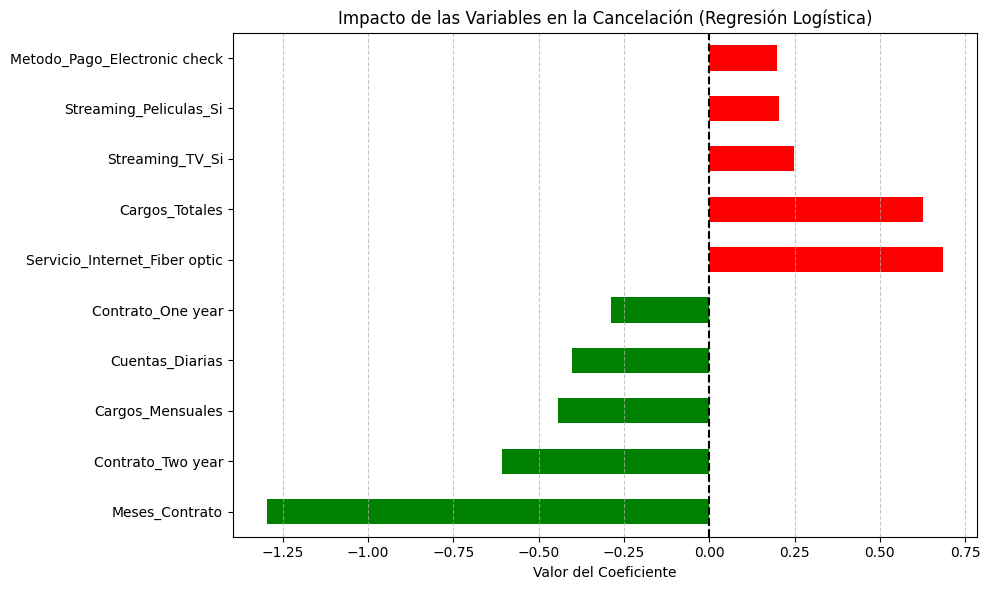

Las 5 variables que MÁS empujan al cliente a CANCELAR:
Servicio_Internet_Fiber optic    0.685927
Cargos_Totales                   0.625132
Streaming_TV_Si                  0.249608
Streaming_Peliculas_Si           0.204004
Metodo_Pago_Electronic check     0.199184
dtype: float64

Las 5 variables que MÁS ayudan a RETENER al cliente:
Meses_Contrato      -1.297335
Contrato_Two year   -0.606897
Cargos_Mensuales    -0.442892
Cuentas_Diarias     -0.403104
Contrato_One year   -0.286764
dtype: float64


In [10]:
# Extraer coeficientes de la Regresión Logística
coeficientes = pd.Series(lr.coef_[0], index=X.columns)

# Separar las top 5 que favorecen la cancelación y las top 5 que la previenen
top_cancelacion = coeficientes.sort_values(ascending=False).head(5)
top_retencion = coeficientes.sort_values(ascending=True).head(5)

# Unir ambos para la gráfica
top_impacto = pd.concat([top_retencion, top_cancelacion])

# Colores: Verde para retención (negativos), Rojo para cancelación (positivos)
colores = ['green' if x < 0 else 'red' for x in top_impacto.values]

plt.figure(figsize=(10, 6))
top_impacto.plot(kind='barh', color=colores)
plt.title("Impacto de las Variables en la Cancelación (Regresión Logística)")
plt.xlabel("Valor del Coeficiente")
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir reporte textual
print("Las 5 variables que MÁS empujan al cliente a CANCELAR:")
print(top_cancelacion)
print("\nLas 5 variables que MÁS ayudan a RETENER al cliente:")
print(top_retencion)

# Informe Estratégico: Análisis de Cancelación de Clientes (Churn) y Estrategias de Retención

---

## 1. Rendimiento de los Modelos Predictivos
Para predecir qué clientes tienen mayor probabilidad de cancelar sus servicios, se entrenaron y evaluaron dos modelos de clasificación: **Regresión Logística** (con datos normalizados) y **Random Forest** (sin normalizar).

| Modelo | Exactitud (Test) | Recall (Sensibilidad) | Diagnóstico |
| :--- | :---: | :---: | :--- |
| **Random Forest** | 78.6% | 46.8% | **Sobreajuste (Overfitting):** Memorizó datos de entrenamiento (99.6%) pero falló al generalizar. |
| **Regresión Logística** | **Óptimo** | **78.3%** | **Modelo Seleccionado:** Rendimiento estable que permite detectar la gran mayoría de las fugas a tiempo. |

> [!TIP]
> En el contexto de retención, es preferible un modelo con **alto Recall** para minimizar los falsos negativos y asegurar que no perdamos de vista a clientes en riesgo.

---

## 2. Principales Factores que Influyen en la Cancelación
Basado en los coeficientes de la **Regresión Logística**, estos son los factores con mayor impacto en la decisión del cliente:

### 🚩 Factores de Riesgo (Impulsan la cancelación)
* **Contratos "Mes a Mes" (Month-to-month):** Es el factor número uno de abandono. Clientes sin compromiso a largo plazo son altamente volátiles.
* **Servicio de Fibra Óptica:** Presentan una tasa de cancelación inusualmente alta (posibles problemas de calidad o precio).
* **Método de Pago (Cheque Electrónico):** Mayor "fricción" manual al pagar, facilitando la decisión de abandono mensual.
* **Cargos Totales Altos:** Correlación directa entre el aumento histórico de la factura y la búsqueda de alternativas económicas.

### ✅ Factores de Retención (Previenen la cancelación)
* **Contratos a Largo Plazo:** Los contratos de 1 o 2 años actúan como el ancla principal de retención.
* **Antigüedad (Meses_Contrato):** A medida que el cliente supera los meses críticos iniciales, la probabilidad de fuga disminuye drásticamente.

---

## 3. Estrategias de Retención Propuestas

### **Estrategia 1: Migración a Contratos Anuales**
* **Acción:** Diseñar campañas agresivas de *upselling* dirigidas a clientes "Mes a Mes".
* **Incentivo:** Ofrecer descuentos exclusivos, *upgrades* de velocidad o meses gratis a cambio de contratos de 1 o 2 años.

### **Estrategia 2: Auditoría del Servicio de Fibra Óptica**
* **Acción:** Iniciar investigación técnica y de mercado urgente.
* **Incentivo:** Encuestar a clientes actuales y desertores para identificar si el problema radica en el precio, el servicio al cliente o la estabilidad de la red.

### **Estrategia 3: Incentivar la Automatización de Pagos**
* **Acción:** Crear programa de beneficios para migrar de "Cheque Electrónico" a "Cobro Automático".
* **Incentivo:** Pequeño porcentaje de descuento en la factura para reducir la fricción de pago y la decisión consciente de renovar cada mes.

### **Estrategia 4: Programa de Fidelización Temprana**
* **Acción:** Enfocar esfuerzos de *onboarding* y servicio al cliente durante los **primeros 6 meses**.
* **Incentivo:** Asegurar una experiencia sin fricciones en el periodo de mayor vulnerabilidad para garantizar la permanencia a largo plazo.